In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [27]:
#conectar con la base de datos y cargar las 3 tablas
import sqlite3

db_path = "../data/raw/mercado_inmobiliario.db"

with sqlite3.connect(db_path) as conn:
    listings = pd.read_sql("SELECT * FROM listings", conn)
    listings_det = pd.read_sql("SELECT * FROM listings_det", conn)
    precio = pd.read_sql("SELECT * FROM df_idealista", conn)

In [28]:
print(listings.shape, listings_det.shape)

(18961, 10) (11529, 11)


In [30]:
#merge de las tablas listings y listings_det con inner join
df_listings = pd.merge(listings, listings_det, on="id", how="inner")
print(df_listings.shape)

(10874, 20)


In [31]:
#merge entre df_listings y precio con left join
df = pd.merge(df_listings, precio, on="neighbourhood_group", how="left")
print(df.shape, df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10874 entries, 0 to 10873
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10874 non-null  int64  
 1   name                          10874 non-null  str    
 2   neighbourhood_group           10874 non-null  str    
 3   neighbourhood                 10874 non-null  str    
 4   latitude                      10874 non-null  float64
 5   longitude                     10874 non-null  float64
 6   room_type_x                   10874 non-null  str    
 7   price                         10874 non-null  float64
 8   minimum_nights                10874 non-null  float64
 9   availability_365              10874 non-null  int64  
 10  description                   10547 non-null  str    
 11  first_review                  10874 non-null  str    
 12  room_type_y                   10874 non-null  str    
 13  accommodates

In [32]:
df = df.drop(columns = ['id','room_type_y'])
df = df.rename(columns = {'price': 'price_night', 'room_type_x': 'room_type'})

## Cálculo del Margen bruto

### Precio por noche adaptado según tipo de inmueble
Se añadirá al cálculo **tasa_uso** el cual va a adaptar el precio por noche total de inmuebles con habitaciones compartidas con mas de un accomodate o con varias habitaciones privadas debido a que no todos los dias las habitaciones estarán completamente llenas. Esto nos permitirá obtener valores mas ajustados a la realidad.

In [33]:
#precio noche total para cada tipo de room con tasa de uso segun room_type
tasa_uso = 0.5

condiciones = [
    (df['room_type'] == 'Entire home/apt'),
    (df['room_type'] == 'Private room') & (df['bedrooms'] == 1),
    (df['room_type'] == 'Private room') & (df['bedrooms'] > 1),
    (df['room_type'] == 'Shared room') & (df['accommodates'] == 1),
    (df['room_type'] == 'Shared room') & (df['accommodates'] > 1)
]
valores = [
    df['price_night'],
    df['price_night'] * df['bedrooms'],
    df['price_night'] * df['bedrooms'] * tasa_uso,
    df['price_night'] * df['accommodates'],
    df['price_night'] * df['accommodates'] * tasa_uso,
]

df['total_price_night'] = np.select(condiciones, valores, default=np.nan)

In [34]:
df['price_night'].isna().sum()

np.int64(0)

In [35]:
#comprovacion de la tasa de uso (0.5) para shared room
df.loc[(df.room_type == 'Shared room') & (df['accommodates'] >2), ['price_night','accommodates','total_price_night',]]

,price_night,accommodates,total_price_night
3069,433.0,8,1732.0
6397,22.0,8,88.0
10229,89.0,6,267.0


### Yearly revenue y gross margin

In [36]:
#crear variable de ingreso_anual como precio_noche_total * estimated_occupancy_l365d
df['yearly_revenue'] = df['total_price_night'] * df['estimated_occupancy_l365d']

Proxy de m2 del inmueble: como no disponemos de una formula del departamento de negocio y éste proyecto es puramente académico se ha calculado el proxy en base a valores arbitrarios usando la IA como guia.

In [37]:
#calcular m2 de cada inmueble para calculos posteriores
condiciones_m2 = [
    (df['bedrooms'] <=1),
    (df['bedrooms'] == 2),
    (df['bedrooms'] == 3) & (df['bathrooms'] < 2),
    (df['bedrooms'] == 3) & (df['bathrooms'] >= 2),
    (df['bedrooms'] > 3) | (df['bathrooms'] >= 3),
]
opciones_m2 = [50, 65, 90, 110, 140]

df['m2_estimated'] = np.select(condiciones_m2, opciones_m2, default=np.nan)


In [38]:
df.m2_estimated.value_counts()

m2_estimated
50.0     7436
65.0     2459
110.0     596
140.0     202
90.0      181
Name: count, dtype: int64

Variable de coste de adquisicion del inmueble

In [39]:
#calcular coste inmueble
df['adquisition_cost'] = df['m2_estimated'] * df['price_m2'] * 0.75

Variable de margen bruto

In [40]:
#crea una variable margen_bruto que sea el reultado de dividir ingreso_anual entre coste_adquisicion
df['gross_margin'] = (df['yearly_revenue'] / df['adquisition_cost'] * 100).round(2)

## Atractivo turistico

In [41]:
#creacion de la variable atractivo turistico
import sys
sys.path.insert(0, '../src')
from preprocessing import tourist_score_0_100

poi_df = pd.read_csv('../data/raw/poi_madrid.csv')

df['tourist_score'] = df.apply(lambda row: tourist_score_0_100(row['latitude'], row['longitude'], poi_df), axis=1)

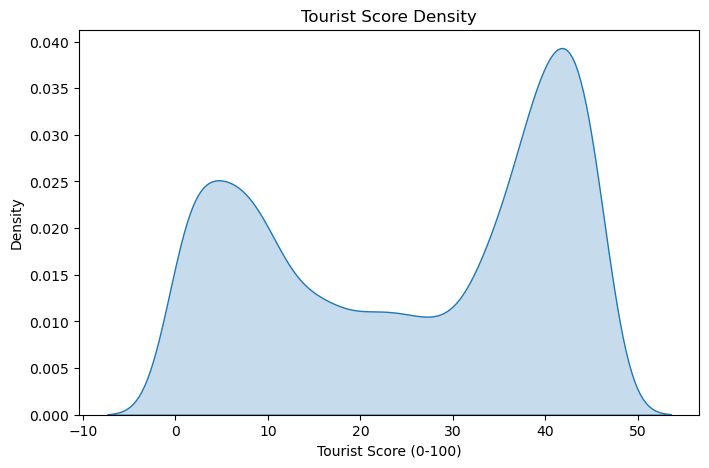

In [42]:
#grafico de densidad para la variable atractivo_turistico
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df['tourist_score'], fill=True)
plt.title('Tourist Score Density')
plt.xlabel('Tourist Score (0-100)')
plt.ylabel('Density')
plt.show()

Observamos que parece que hay 2 grafico superpuestos, uno de 0 a 15 y el otro de 30 a 50. Esto es debido a que posiblemente, haya un grupo de pisos mas enfocados al atractivo turistico y
muchos otros que no lo estan y que su enfoque es mas el alquiler por temporadas largas.  

Discretizacion de variables clave para analisis posterior

In [44]:
#discretiza bedrooms en las categorias 0, 1, 2, 3, 4+
df['bedrooms_disc'] = pd.cut(df['bedrooms'], bins=[-1, 0, 1, 2, 3, np.inf], labels=['0_room', '1_rooms', '2_rooms', '3_rooms', '4+_rooms'])

#discretiza bedrooms en las categorias 0, 1, 2, 3, 4+
df['bathrooms_disc'] = pd.cut(df['bathrooms'], bins=[-np.inf, 1, 2, np.inf], labels=['01_One', '02_Two', '03_Two_or_more'])

#Discretiza accommodates en las categorias 1, 2, 3, 4, 5+
df['accommodates_disc'] = pd.cut(df['accommodates'], bins=[-np.inf, 1, 2, 3, 4, np.inf], labels=['01_One', '02_Two', '03_Three', '04_Four', '05_More_than_four'])

#Discretiza beds en las categorias: '<=1', '2', '3', '4', '>4'
df['beds_disc'] = pd.cut(df['beds'], bins=[-np.inf, 1, 2, 3, 4, np.inf], labels=['1_bed', '2_beds', '3_beds', '4_beds', '5_or_more_beds'])

Exportamosa la db

In [45]:
# Cargar df a la base de datos
with sqlite3.connect(db_path) as conn:
    df.to_sql("tablon_analitico", conn, if_exists="replace", index=False)
    
print(f"DataFrame cargado a la tabla 'df' en {db_path}")


DataFrame cargado a la tabla 'df' en ../data/raw/mercado_inmobiliario.db
